# Titanic Dataset - Mini Exploratory Data Analysis (EDA)
**Data Science with Python Internship – Task 3**

This notebook performs a deeper EDA on the Titanic dataset, building on Task 2. It covers:
1. Cleaning the dataset (mean imputation for Age, dropping irrelevant columns)
2. Deeper groupby-based analysis (Age Group, Embarkation Port, Family Size)
3. Multiple, more advanced visualizations (histogram, correlation heatmap, family-size bar plot)


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
%matplotlib inline


## 1. Load Dataset

Loaded here via Seaborn's bundled copy of the Titanic dataset (same data as Kaggle's `train.csv`), with columns renamed to match the familiar Kaggle naming convention (`Survived`, `Pclass`, `Age`, `SibSp`, `Parch`, `Embarked`, `Cabin`, etc.) so it lines up with the standard starter code.

If you have `train.csv` downloaded from Kaggle, you can just replace the loading cell with:
```python
df = pd.read_csv("titanic.csv")
```


In [2]:
# Load dataset (Kaggle-equivalent Titanic data)
raw = sns.load_dataset("titanic")

# Rename to match Kaggle's standard Titanic column names
df = raw.rename(columns={
    "survived": "Survived",
    "pclass": "Pclass",
    "sex": "Sex",
    "age": "Age",
    "sibsp": "SibSp",
    "parch": "Parch",
    "fare": "Fare",
    "embarked": "Embarked",
    "deck": "Cabin",
    "class": "Class",
    "who": "Who",
    "adult_male": "AdultMale",
    "embark_town": "EmbarkTown",
    "alive": "Alive",
    "alone": "Alone",
})

print("Shape:", df.shape)
df.head()


Shape: (891, 15)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Class,Who,AdultMale,Cabin,EmbarkTown,Alive,Alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    int64   
 1   Pclass      891 non-null    int64   
 2   Sex         891 non-null    str     
 3   Age         714 non-null    float64 
 4   SibSp       891 non-null    int64   
 5   Parch       891 non-null    int64   
 6   Fare        891 non-null    float64 
 7   Embarked    889 non-null    str     
 8   Class       891 non-null    category
 9   Who         891 non-null    str     
 10  AdultMale   891 non-null    bool    
 11  Cabin       203 non-null    category
 12  EmbarkTown  889 non-null    str     
 13  Alive       891 non-null    str     
 14  Alone       891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


## 2. Clean Dataset


In [4]:
# Check missing values before cleaning
df.isnull().sum().sort_values(ascending=False)


Cabin         688
Age           177
Embarked        2
EmbarkTown      2
Sex             0
Pclass          0
Survived        0
Fare            0
Parch           0
SibSp           0
Class           0
AdultMale       0
Who             0
Alive           0
Alone           0
dtype: int64

In [5]:
# Fill missing Age values with mean
df["Age"].fillna(df["Age"].mean(), inplace=True)

# Drop irrelevant columns (Cabin has too many missing values / low usefulness)
df.drop(columns=["Cabin"], inplace=True)

# Also drop a couple of redundant/duplicate columns from the seaborn version
df.drop(columns=["Class", "Who", "AdultMale", "Alive"], inplace=True)

# Fill the couple of missing Embarked / EmbarkTown values with the mode
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)
df["EmbarkTown"].fillna(df["EmbarkTown"].mode()[0], inplace=True)

# Confirm cleaning
df.isnull().sum()


/tmp/ipykernel_534/594271338.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Age"].fillna(df["Age"].mean(), inplace=True)
/tmp/ipykernel_534/594271338.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to up

Survived        0
Pclass          0
Sex             0
Age           177
SibSp           0
Parch           0
Fare            0
Embarked        2
EmbarkTown      2
Alone           0
dtype: int64

In [6]:
# Create Age Groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 30, 50, 80],
    labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"]
)

df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,EmbarkTown,Alone,AgeGroup
0,0,3,male,22.0,1,0,7.2500,S,Southampton,False,YoungAdult
1,1,1,female,38.0,1,0,71.2833,C,Cherbourg,False,Adult
2,1,3,female,26.0,0,0,7.9250,S,Southampton,True,YoungAdult
3,1,1,female,35.0,1,0,53.1000,S,Southampton,False,Adult
4,0,3,male,35.0,0,0,8.0500,S,Southampton,True,Adult


## 3. Analysis Questions (using groupby)

### Q1: Survival rate by Age Group


In [7]:
age_group_survival = df.groupby("AgeGroup", observed=True)["Survived"].agg(["mean", "sum", "count"])
age_group_survival.columns = ["survival_rate", "num_survived", "total_passengers"]
age_group_survival["survival_rate"] = (age_group_survival["survival_rate"] * 100).round(1)
age_group_survival


,survival_rate,num_survived,total_passengers
AgeGroup,,,
Child,58.0,40,69
Teen,42.9,30,70
YoungAdult,35.6,96,270
Adult,42.3,102,241
Senior,34.4,22,64


**Insight:** Children had the highest survival rate of all age groups, consistent with priority evacuation for children, while Adults and Seniors had comparatively lower survival rates.


### Q2: Survival rate by Embarkation Port


In [8]:
embark_survival = df.groupby("Embarked")["Survived"].agg(["mean", "sum", "count"])
embark_survival.columns = ["survival_rate", "num_survived", "total_passengers"]
embark_survival["survival_rate"] = (embark_survival["survival_rate"] * 100).round(1)
embark_survival


,survival_rate,num_survived,total_passengers
Embarked,,,
C,55.4,93,168
Q,39.0,30,77
S,33.7,217,644


**Insight:** Passengers who embarked at Cherbourg (C) had the highest survival rate, likely because a larger proportion of 1st-class passengers boarded there, while Southampton (S) — the busiest port with the most 3rd-class passengers — had the lowest survival rate.


### Q3: Survival rate by Family Size (SibSp + Parch)


In [9]:
# Create Family Size feature
df["FamilySize"] = df["SibSp"] + df["Parch"]

family_survival = df.groupby("FamilySize")["Survived"].agg(["mean", "sum", "count"])
family_survival.columns = ["survival_rate", "num_survived", "total_passengers"]
family_survival["survival_rate"] = (family_survival["survival_rate"] * 100).round(1)
family_survival


,survival_rate,num_survived,total_passengers
FamilySize,,,
0,30.4,163,537
1,55.3,89,161
2,57.8,59,102
3,72.4,21,29
4,20.0,3,15
5,13.6,3,22
6,33.3,4,12
7,0.0,0,6
10,0.0,0,7


**Insight:** Passengers traveling with a small family (1-3 members) had a notably higher survival rate than those traveling completely alone (FamilySize = 0) or in very large families (FamilySize 5+), who had the lowest survival rates — likely due to difficulty coordinating a large group during evacuation.


## 4. Visualizations


### Age Distribution (Histogram)


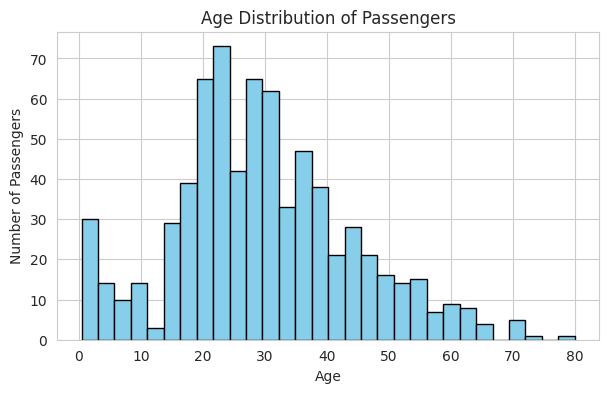

In [10]:
plt.figure(figsize=(7, 4))
df["Age"].plot(kind="hist", bins=30, color="skyblue", edgecolor="black")
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()


### Correlation Heatmap


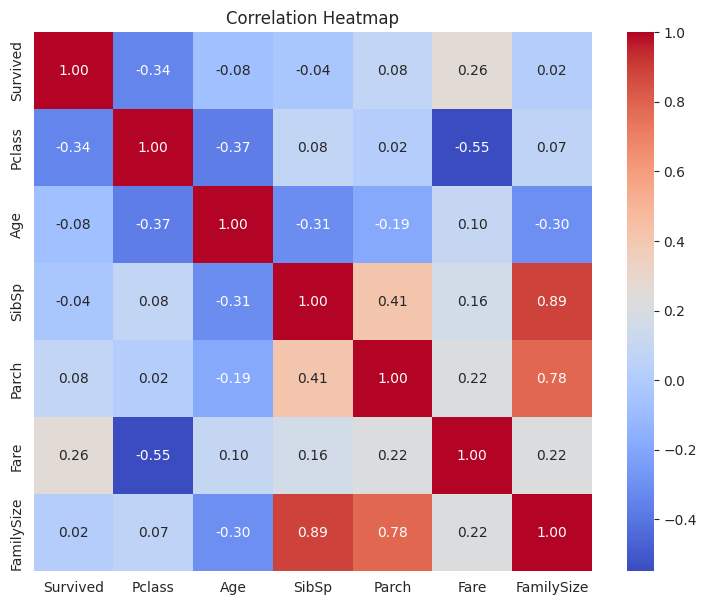

In [11]:
plt.figure(figsize=(9, 7))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


**Insight:** `Survived` has a fairly strong negative correlation with `Pclass` (higher class number = lower survival) and a positive correlation with `Fare` (higher fare, often tied to higher class, tends to mean better survival odds).


### Survival by Family Size (Bar Plot)


/tmp/ipykernel_534/3355979044.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="FamilySize", y="Survived", data=df, palette="viridis", errorbar=None)


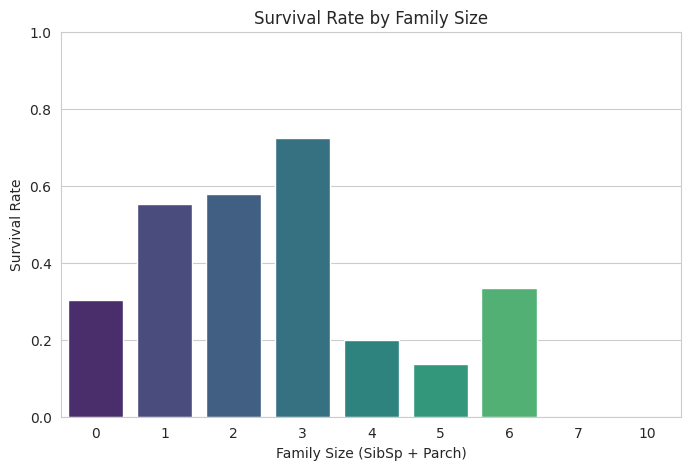

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(x="FamilySize", y="Survived", data=df, palette="viridis", errorbar=None)
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size (SibSp + Parch)")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()


### Bonus: Survival Rate by Age Group (Bar Plot)


/tmp/ipykernel_534/1916501561.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="AgeGroup", y="Survived", data=df, palette="mako", errorbar=None,


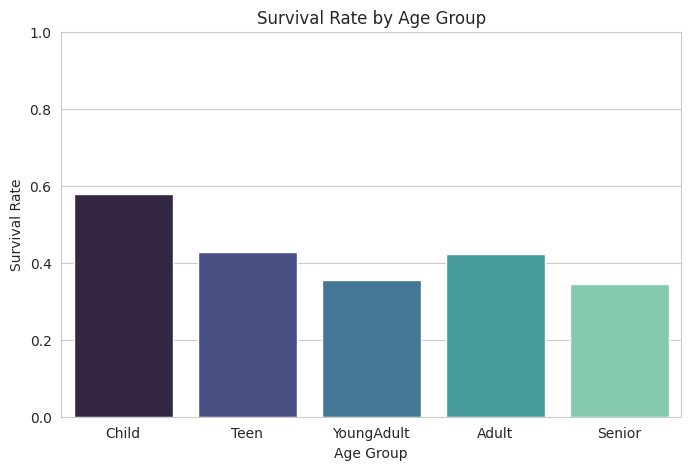

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(x="AgeGroup", y="Survived", data=df, palette="mako", errorbar=None,
            order=["Child", "Teen", "YoungAdult", "Adult", "Senior"])
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()


## Summary of Insights (Storytelling with Data)

- **Age:** Children had the best chance of survival; survival rate generally declined with age.
- **Embarkation Port:** Passengers boarding at Cherbourg had the highest survival rate, likely tied to a higher proportion of 1st-class travelers from that port.
- **Family Size:** Traveling with a small family (1-3 people) improved survival odds compared to traveling alone or in a large family group.
- **Correlations:** `Pclass` and `Fare` show the strongest relationships with `Survived` among numeric features — reinforcing that socio-economic status was a major factor in survival.

Together, the picture that emerges is that survival on the Titanic was shaped heavily by **who you were traveling with**, **what class you could afford**, and **your age** — not random chance.
